In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import folium


In [2]:
# menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [23]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("dataGempadunia.csv")
df.head()


Saving dataGempadunia.csv to dataGempadunia (1).csv


,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  object 
 1   Time                        23412 non-null  object 
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  object 
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23409 non-null  object 
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         160

In [25]:
df.describe()

,Latitude,Longitude,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Error,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square
count,23412.000000,23412.000000,23412.000000,4461.000000,7097.000000,23412.000000,327.000000,2564.000000,7299.000000,1604.000000,1156.000000,17352.000000
mean,1.679033,39.639961,70.767911,4.993115,275.364098,5.882531,0.071820,48.944618,44.163532,3.992660,7.662759,1.022784
std,30.113183,125.511959,122.651898,4.875184,162.141631,0.423066,0.051466,62.943106,32.141486,5.377262,10.430396,0.188545
min,-77.080000,-179.997000,-1.100000,0.000000,0.000000,5.500000,0.000000,0.000000,0.000000,0.004505,0.085000,0.000000
25%,-18.653000,-76.349750,14.522500,1.800000,146.000000,5.600000,0.046000,10.000000,24.100000,0.968750,5.300000,0.900000
50%,-3.568500,103.982000,33.000000,3.500000,255.000000,5.700000,0.059000,28.000000,36.000000,2.319500,6.700000,1.000000
75%,26.190750,145.026250,54.000000,6.300000,384.000000,6.000000,0.075500,66.000000,54.000000,4.724500,8.100000,1.130000
max,86.005000,179.998000,700.000000,91.295000,934.000000,9.100000,0.410000,821.000000,360.000000,37.874000,99.000000,3.440000


In [26]:
X = df[['Latitude', 'Longitude']]


In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


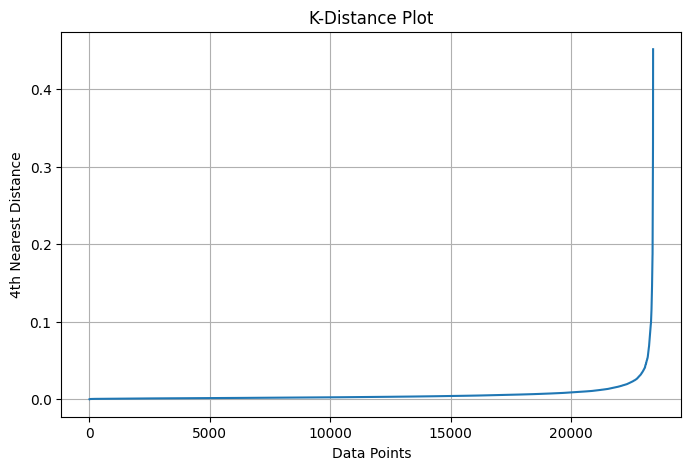

In [28]:
# pakai 4 tetangga
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 3])

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title("K-Distance Plot")
plt.xlabel("Data Points")
plt.ylabel("4th Nearest Distance")
plt.grid(True)
plt.show()


In [29]:
dbscan = DBSCAN(eps=0.20, min_samples=4)
dbscan.fit(X_scaled)

labels = dbscan.labels_


In [30]:
df['Cluster'] = labels
df.head()


,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status,Cluster
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic,0
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic,0
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic,1
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic,0
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic,0


In [31]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_points = list(labels).count(-1)

print("Jumlah Cluster:", n_clusters)
print("Jumlah Noise:", noise_points)


Jumlah Cluster: 5
Jumlah Noise: 14


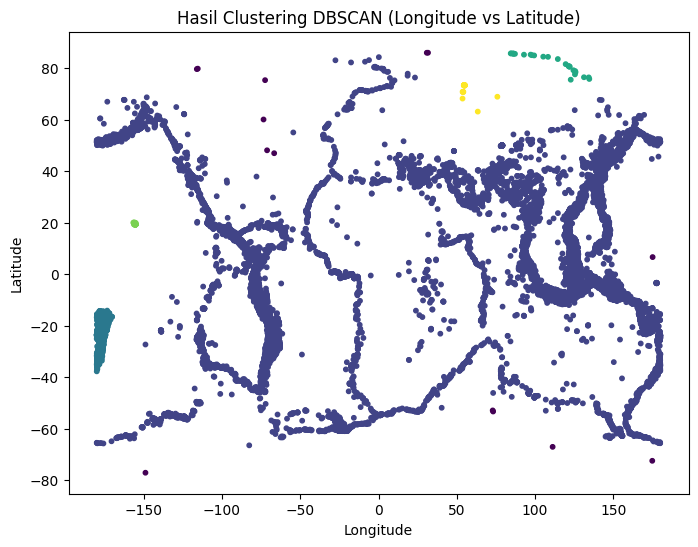

In [32]:
plt.figure(figsize=(8,6))
plt.scatter(df['Longitude'], df['Latitude'], c=labels, s=10)
plt.title("Hasil Clustering DBSCAN (Longitude vs Latitude)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [33]:
center_lat = df['Latitude'].mean()
center_lon = df['Longitude'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=2)

for i, row in df.iterrows():
    color = "black" if row['Cluster'] == -1 else "blue"
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=2,
        color=color,
        fill=True,
        fill_color=color
    ).add_to(m)

m


Output hidden; open in https://colab.research.google.com to view.

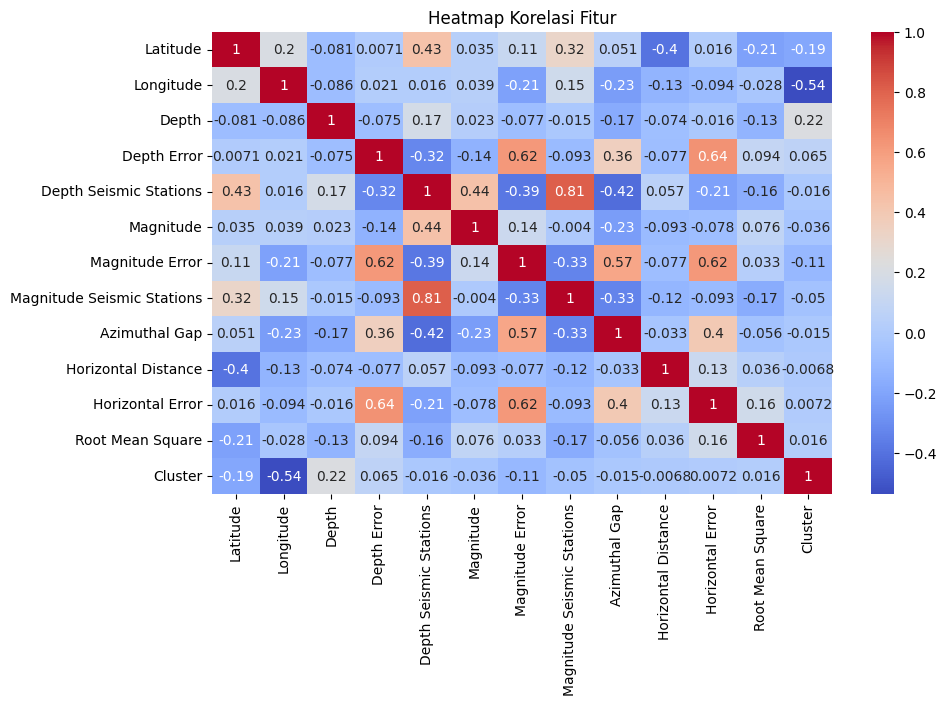

In [35]:
import seaborn as sns
import numpy as np

plt.figure(figsize=(10,6))
# Select only numerical columns for correlation calculation
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi Fitur")
plt.show()

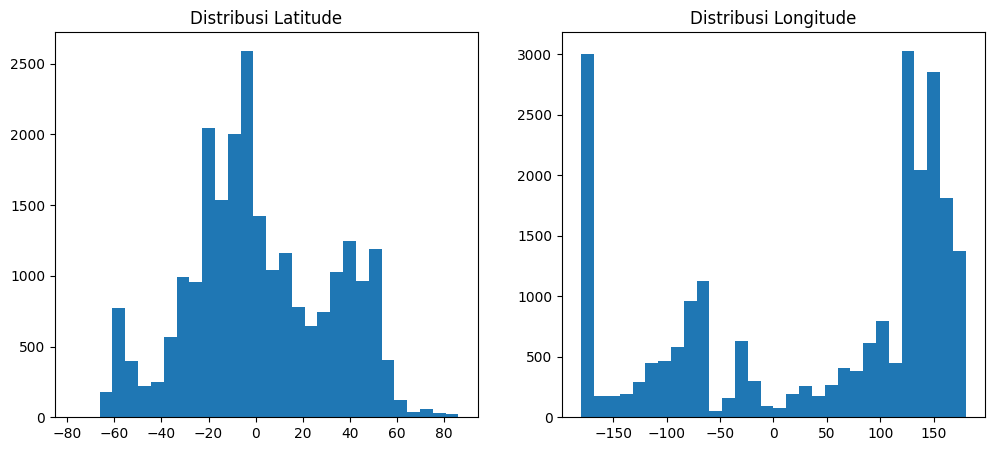

In [36]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(df['Latitude'], bins=30)
plt.title("Distribusi Latitude")

plt.subplot(1,2,2)
plt.hist(df['Longitude'], bins=30)
plt.title("Distribusi Longitude")

plt.show()


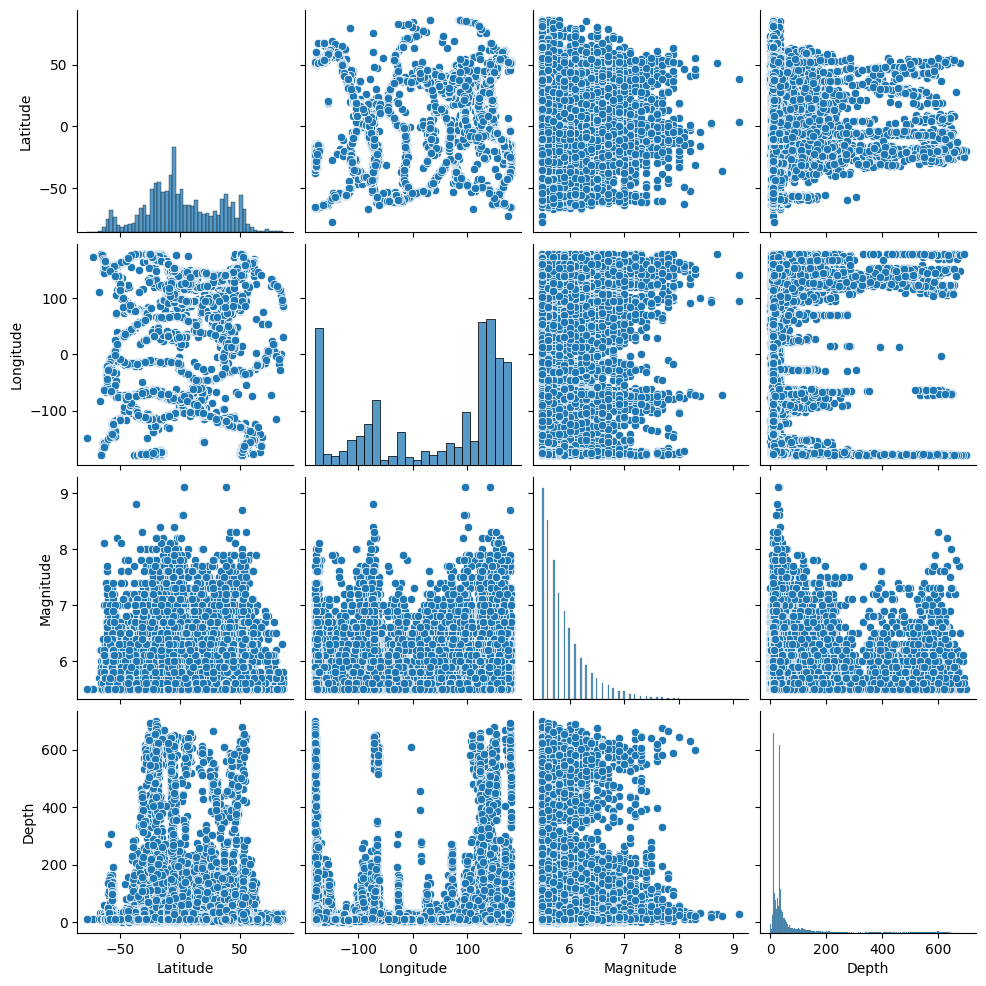

In [37]:
sns.pairplot(df[['Latitude', 'Longitude', 'Magnitude', 'Depth']])
plt.show()


In [38]:
df['Cluster'].value_counts()


,count
Cluster,
0,20743
1,2578
4,27
2,26
3,24
-1,14


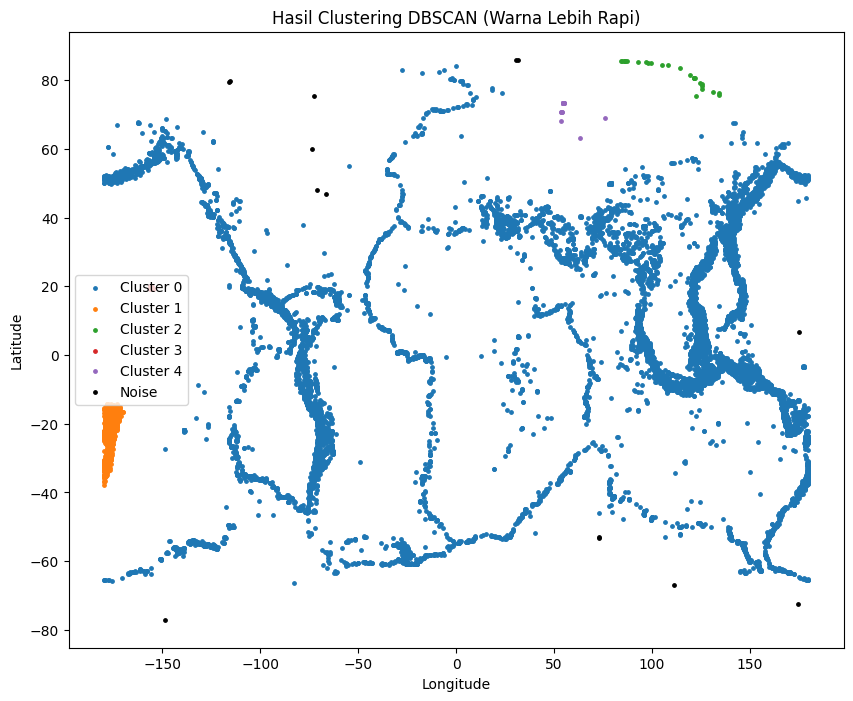

In [39]:
unique_labels = set(labels)

plt.figure(figsize=(10,8))

for lbl in unique_labels:
    cluster_points = df[df['Cluster'] == lbl]
    if lbl == -1:
        color = 'black'
        name = 'Noise'
    else:
        color = plt.cm.tab10(lbl % 10)
        name = f'Cluster {lbl}'

    plt.scatter(cluster_points['Longitude'],
                cluster_points['Latitude'],
                s=6, c=[color], label=name)

plt.legend()
plt.title("Hasil Clustering DBSCAN (Warna Lebih Rapi)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [41]:
df.to_csv("hasil_cluster_gempa.csv", index=False)
